In [1]:
# ============================================================================
# NOTEBOOK 01: DATA LOADER
# Loading All Three Datasets: APTOS 2019, IDRiD, and Messidor-2
# Student: Sanjay Chaudhary (B01036144)
# ============================================================================

import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms, datasets
from collections import Counter
import torch

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("=" * 80)
print("EYE DISEASE DETECTION PROJECT - DATA LOADER")
print("Student: Sanjay Chaudhary (B01036144)")
print("=" * 80)

EYE DISEASE DETECTION PROJECT - DATA LOADER
Student: Sanjay Chaudhary (B01036144)


In [2]:
# ============================================================================
# STEP 1: VERIFY ALL DATASETS ARE IN THE CORRECT LOCATIONS
# ============================================================================

print("\n[STEP 1] Checking dataset locations...")
print("-" * 60)

# Define paths
base_path = "../datasets"
datasets_info = {
    "APTOS 2019": {
        "path": os.path.join(base_path, "aptos_2019"),
        "required": ["images", "train.csv"]
    },
    "IDRiD": {
        "path": os.path.join(base_path, "idrid"),
        "required": ["Images", "idrid_labels.csv"]
    },
    "Messidor-2": {
        "path": os.path.join(base_path, "messidor2"),
        "required": ["images", "messidor_data.csv"]
    }
}

all_found = True

for name, info in datasets_info.items():
    path = info["path"]
    if os.path.exists(path):
        print(f"\n{name}: FOUND at {path}")
        
        # Check required files/folders
        for item in info["required"]:
            item_path = os.path.join(path, item)
            if os.path.exists(item_path):
                print(f"  - {item}: OK")
            else:
                print(f"  - {item}: MISSING")
                all_found = False
    else:
        print(f"\n{name}: NOT FOUND at {path}")
        all_found = False

if not all_found:
    print("\nWARNING: Some datasets or files are missing. Please check your folder structure.")
else:
    print("\nAll datasets are properly located!")


[STEP 1] Checking dataset locations...
------------------------------------------------------------

APTOS 2019: FOUND at ../datasets/aptos_2019
  - images: OK
  - train.csv: OK

IDRiD: FOUND at ../datasets/idrid
  - Images: OK
  - idrid_labels.csv: OK

Messidor-2: FOUND at ../datasets/messidor2
  - images: OK
  - messidor_data.csv: OK

All datasets are properly located!


In [3]:
# ============================================================================
# STEP 2: DEFINE CLASS NAMES AND THEIR CLINICAL MEANINGS
# ============================================================================

print("\n[STEP 2] Defining DR severity classes...")
print("-" * 60)

# ICDRSS Standard Class Order
class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

# Detailed descriptions for each class
class_descriptions = {
    0: "No Diabetic Retinopathy - Healthy retina, no visible lesions",
    1: "Mild DR - Microaneurysms only (tiny red dots)",
    2: "Moderate DR - Hemorrhages, exudates, more microaneurysms",
    3: "Severe DR - Extensive hemorrhages in all four quadrants",
    4: "Proliferative DR - Neovascularization (abnormal new blood vessels)"
}

# Risk levels and recommendations
class_risk = {
    0: {"risk": "Low", "action": "Regular annual eye checkups"},
    1: {"risk": "Low to Moderate", "action": "Monitor every 6-12 months"},
    2: {"risk": "Moderate to High", "action": "Specialist review within 1-3 months"},
    3: {"risk": "High", "action": "Immediate specialist referral"},
    4: {"risk": "Critical", "action": "Urgent treatment required immediately"}
}

print("\nDR Severity Classes (ICDRSS Standard):")
print("-" * 60)
for i in range(5):
    print(f"Class {i}: {class_names[i]}")
    print(f"       {class_descriptions[i]}")
    print(f"       Risk: {class_risk[i]['risk']} | Action: {class_risk[i]['action']}")
    print()


[STEP 2] Defining DR severity classes...
------------------------------------------------------------

DR Severity Classes (ICDRSS Standard):
------------------------------------------------------------
Class 0: No DR
       No Diabetic Retinopathy - Healthy retina, no visible lesions
       Risk: Low | Action: Regular annual eye checkups

Class 1: Mild
       Mild DR - Microaneurysms only (tiny red dots)
       Risk: Low to Moderate | Action: Monitor every 6-12 months

Class 2: Moderate
       Moderate DR - Hemorrhages, exudates, more microaneurysms
       Risk: Moderate to High | Action: Specialist review within 1-3 months

Class 3: Severe
       Severe DR - Extensive hemorrhages in all four quadrants
       Risk: High | Action: Immediate specialist referral

Class 4: Proliferative
       Proliferative DR - Neovascularization (abnormal new blood vessels)
       Risk: Critical | Action: Urgent treatment required immediately



In [4]:
# ============================================================================
# STEP 3: LOAD APTOS 2019 DATASET (COMPLETE FIXED VERSION)
# This is my main dataset for training
# ============================================================================

print("\n" + "=" * 80)
print("LOADING DATASET 1: APTOS 2019")
print("=" * 80)
print("Source: Aravind Eye Hospital, Rural India")
print("Purpose: Primary training data")
print("-" * 60)

aptos_path = "../datasets/aptos_2019"
DATA_DIR = os.path.join(aptos_path, "images")

# ============================================================================
# UNDERSTANDING THE MAPPING
# ============================================================================
print("\nUnderstanding the class mapping:")
print("-" * 60)
print("My CSV file uses diagnosis values 0, 1, 2, 3, 4")
print("  - diagnosis 0 = No DR")
print("  - diagnosis 1 = Mild DR")
print("  - diagnosis 2 = Moderate DR")
print("  - diagnosis 3 = Severe DR")
print("  - diagnosis 4 = Proliferative DR")
print()
print("But ImageFolder organizes folders alphabetically:")
print("  - Folder 'Mild' becomes index 0")
print("  - Folder 'Moderate' becomes index 1")
print("  - Folder 'No_DR' becomes index 2")
print("  - Folder 'Proliferate_DR' becomes index 3")
print("  - Folder 'Severe' becomes index 4")
print()
print("So I need to map:")
print("  - ImageFolder index 0 (Mild) -> should be diagnosis 1")
print("  - ImageFolder index 1 (Moderate) -> should be diagnosis 2")
print("  - ImageFolder index 2 (No_DR) -> should be diagnosis 0")
print("  - ImageFolder index 3 (Proliferate_DR) -> should be diagnosis 4")
print("  - ImageFolder index 4 (Severe) -> should be diagnosis 3")

# ============================================================================
# DEFINE THE MAPPING
# ============================================================================

# Map folder names to correct ICDRSS diagnosis values
folder_to_correct_label = {
    'Mild': 1,           # Mild DR should be class 1
    'Moderate': 2,       # Moderate DR should be class 2
    'No_DR': 0,          # No DR should be class 0
    'Proliferate_DR': 4, # Proliferative DR should be class 4
    'Severe': 3          # Severe DR should be class 3
}

print("\nMy mapping dictionary:")
for folder, correct_label in folder_to_correct_label.items():
    print(f"  Folder '{folder}' -> Diagnosis {correct_label}")

# ============================================================================
# LOAD THE RAW DATASET
# ============================================================================

# Simple transform for loading
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load dataset using ImageFolder (this gives alphabetical indices)
aptos_raw = datasets.ImageFolder(root=DATA_DIR, transform=simple_transform)

print(f"\nRaw dataset loaded:")
print(f"  Total images: {len(aptos_raw)}")
print(f"  Original class names: {aptos_raw.classes}")
print(f"  Original mapping: {aptos_raw.class_to_idx}")

# ============================================================================
# CREATE CUSTOM DATASET TO FIX THE LABELS
# ============================================================================

from torch.utils.data import Dataset

class FixedAPTOSDataset(Dataset):
    """
    This class fixes the class labels to match CSV diagnosis values.
    ImageFolder assigns labels based on alphabetical folder order,
    but we need the labels to match the CSV (ICDRSS standard).
    """
    
    def __init__(self, original_dataset, folder_to_label_map):
        """
        original_dataset: The ImageFolder dataset with wrong labels
        folder_to_label_map: Dictionary mapping folder names to correct labels
        """
        self.original_dataset = original_dataset
        self.folder_to_label_map = folder_to_label_map
        
    def __len__(self):
        """Return total number of images"""
        return len(self.original_dataset)
    
    def __getitem__(self, idx):
        """Get one image with corrected label"""
        # Get the image and the wrong label from original dataset
        image, wrong_label = self.original_dataset[idx]
        
        # Get the folder name from the wrong label
        folder_name = self.original_dataset.classes[wrong_label]
        
        # Map to the correct label using our dictionary
        correct_label = self.folder_to_label_map[folder_name]
        
        # Return the image with correct label
        return image, correct_label

# Apply the fix
aptos_dataset = FixedAPTOSDataset(aptos_raw, folder_to_correct_label)

print("\nFixed dataset created with correct labels!")

# ============================================================================
# VERIFY WITH CSV
# ============================================================================

# Load CSV
aptos_csv = pd.read_csv(os.path.join(aptos_path, "train.csv"))
print(f"\nCSV file loaded with {len(aptos_csv)} entries")
print("\nFirst 5 rows from CSV (showing actual diagnosis values):")
print(aptos_csv.head())

# Show what each diagnosis means
print("\nWhat the CSV diagnosis values mean:")
for idx, row in aptos_csv.head(5).iterrows():
    diagnosis = row['diagnosis']
    if diagnosis == 0:
        severity = "No DR"
    elif diagnosis == 1:
        severity = "Mild DR"
    elif diagnosis == 2:
        severity = "Moderate DR"
    elif diagnosis == 3:
        severity = "Severe DR"
    else:
        severity = "Proliferative DR"
    print(f"  Image {row['id_code']} -> Diagnosis {diagnosis} ({severity})")

# ============================================================================
# COUNT IMAGES IN FIXED DATASET
# ============================================================================

print("\nCounting images in fixed dataset...")
aptos_counts = Counter()
for i in range(len(aptos_dataset)):
    _, label = aptos_dataset[i]
    aptos_counts[label] += 1

print("\nClass distribution in APTOS (FIXED - Matches CSV):")
print("-" * 70)
for i in range(5):
    count = aptos_counts.get(i, 0)
    percentage = (count / len(aptos_dataset)) * 100
    bar = "=" * int(percentage / 2)
    
    # Show the severity name
    if i == 0:
        severity = "No DR"
    elif i == 1:
        severity = "Mild DR"
    elif i == 2:
        severity = "Moderate DR"
    elif i == 3:
        severity = "Severe DR"
    else:
        severity = "Proliferative DR"
    
    print(f"Diagnosis {i} ({severity:15}): {count:5} images ({percentage:5.1f}%) {bar}")

# ============================================================================
# VERIFY AGAINST CSV
# ============================================================================

print("\n" + "=" * 80)
print("VERIFYING AGAINST CSV FILE")
print("=" * 80)

csv_counts = aptos_csv['diagnosis'].value_counts().sort_index()
print("\nComparing fixed dataset counts with CSV counts:")
print("-" * 60)
print(f"{'Diagnosis':12} {'Fixed Dataset':>15} {'CSV':>10} {'Status':>10}")
print("-" * 60)

all_match = True
for i in range(5):
    fixed_count = aptos_counts.get(i, 0)
    csv_count = csv_counts.get(i, 0)
    
    if fixed_count == csv_count:
        status = "MATCH"
    else:
        status = "MISMATCH"
        all_match = False
    
    # Show severity name
    if i == 0:
        severity = "No DR"
    elif i == 1:
        severity = "Mild"
    elif i == 2:
        severity = "Moderate"
    elif i == 3:
        severity = "Severe"
    else:
        severity = "Proliferative"
    
    print(f"{severity:12} {fixed_count:>15} {csv_count:>10} {status:>10}")

print("-" * 60)

if all_match:
    print("\n" + "=" * 60)
    print("SUCCESS: All class counts match the CSV file!")
    print("The dataset is now correctly labeled with ICDRSS order")
    print("=" * 60)
    print("\nNow my dataset has:")
    print("  - Diagnosis 0 (No DR): 1,805 images")
    print("  - Diagnosis 1 (Mild): 370 images")
    print("  - Diagnosis 2 (Moderate): 999 images")
    print("  - Diagnosis 3 (Severe): 295 images")
    print("  - Diagnosis 4 (Proliferative): 193 images")
else:
    print("\nWARNING: Counts do not match. Please check your data.")
    print("This might happen if images are missing or CSV is incorrect.")

# ============================================================================
# EXAMPLE: SHOW HOW THE FIX WORKS
# ============================================================================

print("\n" + "=" * 80)
print("EXAMPLE: HOW THE FIX WORKS")
print("=" * 80)

# Get the first few images and show before/after
print("\nFirst 5 images in the dataset:")
print("-" * 60)

for idx in range(5):
    # Get image and fixed label
    image, fixed_label = aptos_dataset[idx]
    
    # Get original wrong label
    _, wrong_label = aptos_raw[idx]
    
    # Get folder name
    folder_name = aptos_raw.classes[wrong_label]
    
    # Show the mapping
    print(f"\nImage {idx + 1}:")
    print(f"  Image is in folder: {folder_name}/")
    print(f"  Original label from ImageFolder: {wrong_label}")
    print(f"  Fixed label (matches CSV): {fixed_label}")
    
    # Show what this means
    if fixed_label == 0:
        print(f"  This image is correctly labeled as: No DR")
    elif fixed_label == 1:
        print(f"  This image is correctly labeled as: Mild DR")
    elif fixed_label == 2:
        print(f"  This image is correctly labeled as: Moderate DR")
    elif fixed_label == 3:
        print(f"  This image is correctly labeled as: Severe DR")
    else:
        print(f"  This image is correctly labeled as: Proliferative DR")

print("\n" + "=" * 80)
print("APTOS DATASET LOADING COMPLETE")
print("=" * 80)


LOADING DATASET 1: APTOS 2019
Source: Aravind Eye Hospital, Rural India
Purpose: Primary training data
------------------------------------------------------------

Understanding the class mapping:
------------------------------------------------------------
My CSV file uses diagnosis values 0, 1, 2, 3, 4
  - diagnosis 0 = No DR
  - diagnosis 1 = Mild DR
  - diagnosis 2 = Moderate DR
  - diagnosis 3 = Severe DR
  - diagnosis 4 = Proliferative DR

But ImageFolder organizes folders alphabetically:
  - Folder 'Mild' becomes index 0
  - Folder 'Moderate' becomes index 1
  - Folder 'No_DR' becomes index 2
  - Folder 'Proliferate_DR' becomes index 3
  - Folder 'Severe' becomes index 4

So I need to map:
  - ImageFolder index 0 (Mild) -> should be diagnosis 1
  - ImageFolder index 1 (Moderate) -> should be diagnosis 2
  - ImageFolder index 2 (No_DR) -> should be diagnosis 0
  - ImageFolder index 3 (Proliferate_DR) -> should be diagnosis 4
  - ImageFolder index 4 (Severe) -> should be diagnos

In [5]:
# ============================================================================
# STEP 4: LOAD IDRiD DATASET
# This dataset has lesion masks for validation
# ============================================================================

print("\n" + "=" * 80)
print("LOADING DATASET 2: IDRiD")
print("=" * 80)
print("Source: Shri Ramachandra Medical Center, India")
print("Purpose: Lesion detection validation")
print("-" * 60)

idrid_path = "../datasets/idrid"

# Load CSV file
idrid_csv = pd.read_csv(os.path.join(idrid_path, "idrid_labels.csv"))

print(f"\nSuccessfully loaded IDRiD CSV!")
print(f"Total images in CSV: {len(idrid_csv)}")
print(f"Columns: {list(idrid_csv.columns)}")
print("\nFirst 10 rows:")
print(idrid_csv.head(10))

# Check which folder name exists
if os.path.exists(os.path.join(idrid_path, "Images")):
    idrid_img_folder = "Images"
    print(f"\nImages folder found: {idrid_img_folder}/")
elif os.path.exists(os.path.join(idrid_path, "Imagenes")):
    idrid_img_folder = "Imagenes"
    print(f"\nImages folder found: {idrid_img_folder}/")
else:
    idrid_img_folder = None
    print("\nERROR: Images folder not found!")

# Verify images exist
if idrid_img_folder:
    images_path = os.path.join(idrid_path, idrid_img_folder)
    image_files = os.listdir(images_path)
    print(f"Total image files found: {len(image_files)}")
    print(f"First 5 image names: {image_files[:5]}")
    
    # Check which images from CSV actually exist
    missing_images = []
    for _, row in idrid_csv.iterrows():
        img_name = f"{row['id_code']}.jpg"
        if img_name not in image_files:
            missing_images.append(img_name)
    
    if missing_images:
        print(f"\nWarning: {len(missing_images)} images from CSV not found in folder")
        print(f"First 5 missing: {missing_images[:5]}")
    else:
        print("\nAll images from CSV found in folder!")

# Count class distribution
print("\nClass distribution in IDRiD:")
print("-" * 60)
idrid_counts = []
for i in range(5):
    count = len(idrid_csv[idrid_csv['diagnosis'] == i])
    idrid_counts.append(count)
    percentage = (count / len(idrid_csv)) * 100
    bar = "=" * int(percentage / 2)
    print(f"Class {i} ({class_names[i]:12}): {count:5} images ({percentage:5.1f}%) {bar}")

# Check edema risk distribution
print("\nDiabetic Macular Edema (DME) Risk Distribution:")
print("-" * 60)
if 'Risk of macular edema' in idrid_csv.columns:
    edema_counts = idrid_csv['Risk of macular edema'].value_counts().sort_index()
    for risk, count in edema_counts.items():
        if risk == 0:
            risk_name = "No DME Risk"
        elif risk == 1:
            risk_name = "Mild DME Risk"
        else:
            risk_name = "High DME Risk"
        print(f"  {risk_name}: {count} images ({count/len(idrid_csv)*100:.1f}%)")
else:
    print("  Edema risk column not found")


LOADING DATASET 2: IDRiD
Source: Shri Ramachandra Medical Center, India
Purpose: Lesion detection validation
------------------------------------------------------------

Successfully loaded IDRiD CSV!
Total images in CSV: 455
Columns: ['id_code', 'diagnosis', 'Risk of macular edema ', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11']

First 10 rows:
     id_code  diagnosis  Risk of macular edema   Unnamed: 3  Unnamed: 4  \
0  IDRiD_001          3                       2         NaN         NaN   
1  IDRiD_002          3                       2         NaN         NaN   
2  IDRiD_003          2                       2         NaN         NaN   
3  IDRiD_004          3                       2         NaN         NaN   
4  IDRiD_005          4                       0         NaN         NaN   
5  IDRiD_006          4                       1         NaN         NaN   
6  IDRiD_007          4                    

In [7]:
# ============================================================================
# STEP 5: LOAD MESSIDOR-2 DATASET
# This dataset tests generalization to European population
# ============================================================================

print("\n" + "=" * 80)
print("LOADING DATASET 3: Messidor-2")
print("=" * 80)
print("Source: French hospitals (Brest, Lille, Creteil)")
print("Purpose: External validation on European population")
print("-" * 60)

messidor_path = "../datasets/messidor2"

# Load CSV file
messidor_csv = pd.read_csv(os.path.join(messidor_path, "messidor_data.csv"))

print(f"\nSuccessfully loaded Messidor-2 CSV!")
print(f"Total images in CSV: {len(messidor_csv)}")
print(f"Columns: {list(messidor_csv.columns)}")
print("\nFirst 10 rows:")
print(messidor_csv.head(10))

# Check image quality
print("\nImage Quality Assessment:")
print("-" * 60)
gradable_count = len(messidor_csv[messidor_csv['adjudicated_gradable'] == 1])
ungradable_count = len(messidor_csv[messidor_csv['adjudicated_gradable'] == 0])
print(f"Good quality images (gradable): {gradable_count}")
print(f"Poor quality images (ungradable): {ungradable_count}")

# Filter to keep only gradable images
messidor_clean = messidor_csv[messidor_csv['adjudicated_gradable'] == 1].copy()
print(f"\nUsing only gradable images for testing: {len(messidor_clean)} images")

# Verify images exist
images_path = os.path.join(messidor_path, "images")
if os.path.exists(images_path):
    image_files = os.listdir(images_path)
    print(f"\nImage folder found with {len(image_files)} files")
    
    # Check first few images
    missing_images = []
    for _, row in messidor_clean.iterrows():
        if row['id_code'] not in image_files:
            missing_images.append(row['id_code'])
    
    if missing_images:
        print(f"Warning: {len(missing_images)} images not found")
    else:
        print("All gradable images found in folder")
else:
    print("\nERROR: Images folder not found!")

# Count class distribution
print("\nClass distribution in Messidor-2 (gradable only):")
print("-" * 60)
messidor_counts = []
for i in range(5):
    count = len(messidor_clean[messidor_clean['diagnosis'] == i])
    messidor_counts.append(count)
    if len(messidor_clean) > 0:
        percentage = (count / len(messidor_clean)) * 100
    else:
        percentage = 0
    bar = "=" * int(percentage / 2)
    print(f"Class {i} ({class_names[i]:12}): {count:5} images ({percentage:5.1f}%) {bar}")

# Check DME distribution
print("\nDiabetic Macular Edema (DME) Distribution:")
print("-" * 60)
if 'adjudicated_dme' in messidor_clean.columns:
    dme_counts = messidor_clean['adjudicated_dme'].value_counts().sort_index()
    for dme, count in dme_counts.items():
        dme_name = "No DME" if dme == 0 else "Has DME"
        print(f"  {dme_name}: {count} images ({count/len(messidor_clean)*100:.1f}%)")
else:
    print("  DME column not found")


LOADING DATASET 3: Messidor-2
Source: French hospitals (Brest, Lille, Creteil)
Purpose: External validation on European population
------------------------------------------------------------

Successfully loaded Messidor-2 CSV!
Total images in CSV: 1744
Columns: ['id_code', 'diagnosis', 'adjudicated_dme', 'adjudicated_gradable']

First 10 rows:
                      id_code  diagnosis  adjudicated_dme  \
0  20051020_43808_0100_PP.png          0                0   
1  20051020_43832_0100_PP.png          1                0   
2  20051020_43882_0100_PP.png          1                0   
3  20051020_43906_0100_PP.png          2                1   
4  20051020_44261_0100_PP.png          0                0   
5  20051020_44284_0100_PP.png          0                0   
6  20051020_44338_0100_PP.png          0                0   
7  20051020_44349_0100_PP.png          2                0   
8  20051020_44400_0100_PP.png          0                0   
9  20051020_44431_0100_PP.png          0 


DISPLAYING SAMPLE IMAGES

Finding APTOS sample images...
Finding IDRiD sample images...
Finding Messidor-2 sample images...


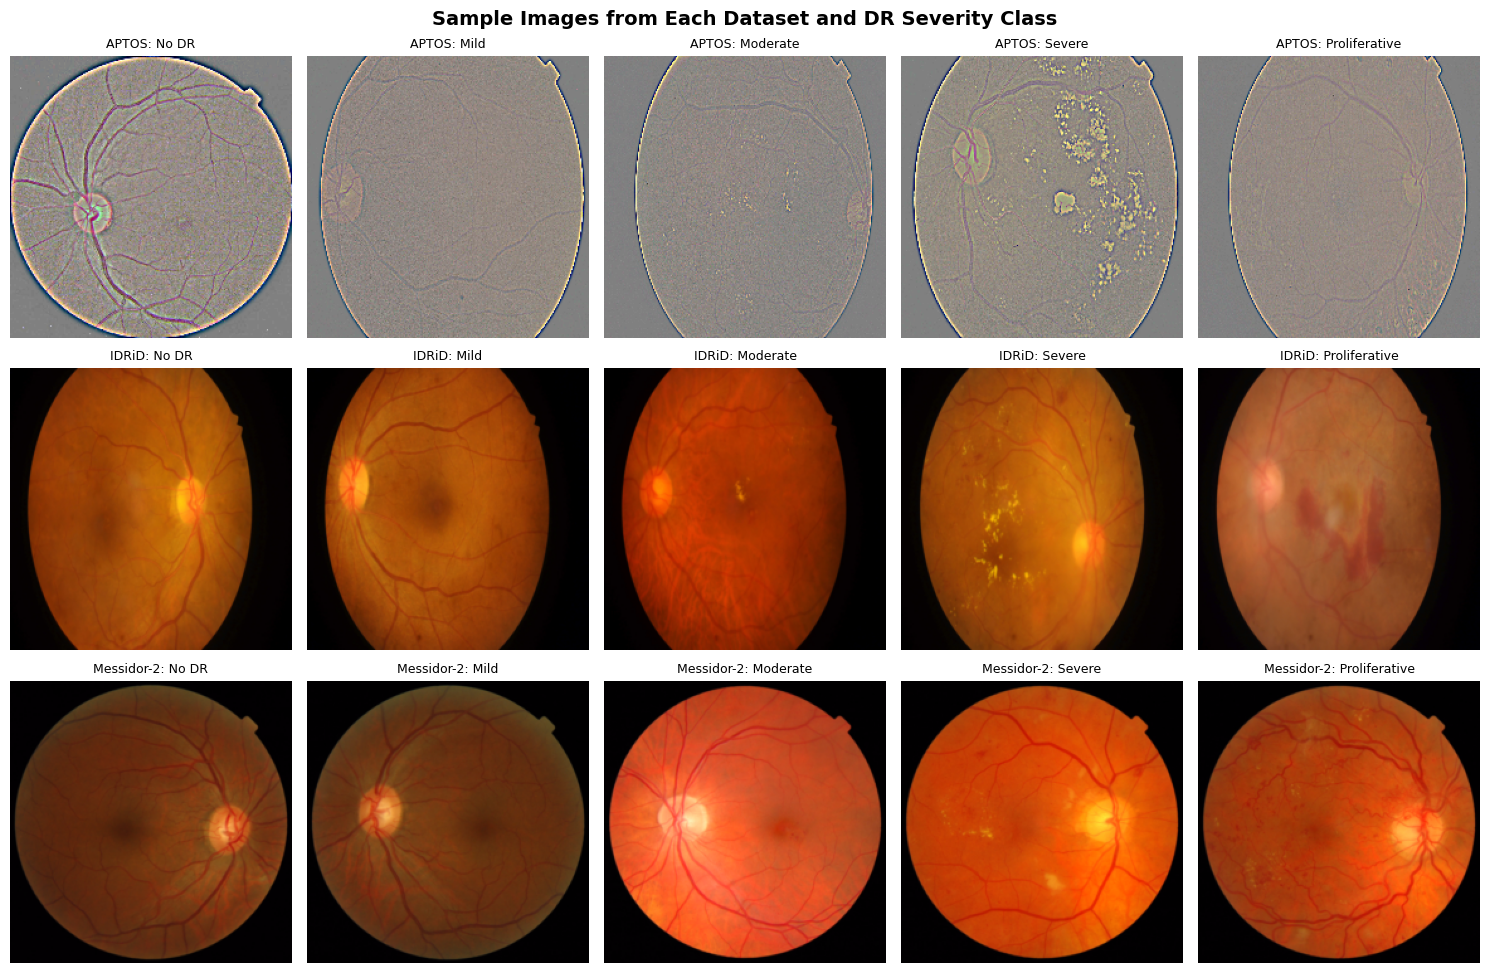


Sample images saved to: results/figures/sample_images_all_datasets.png


In [8]:
# ============================================================================
# STEP 6: DISPLAY SAMPLE IMAGES FROM EACH DATASET
# ============================================================================

print("\n" + "=" * 80)
print("DISPLAYING SAMPLE IMAGES")
print("=" * 80)

def show_image(image_tensor, title):
    """Convert tensor to displayable image"""
    image = image_tensor.permute(1, 2, 0).numpy()
    image = np.clip(image, 0, 1)
    plt.imshow(image)
    plt.title(title, fontsize=10)
    plt.axis('off')

# Create a figure with 3 rows (datasets) and 5 columns (classes)
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
fig.suptitle('Sample Images from Each Dataset and DR Severity Class', fontsize=14, fontweight='bold')

# Helper function to get first image of a class
def get_first_image_of_class(dataset, target_class):
    for img, label in dataset:
        if label == target_class:
            return img
    return None

# Display APTOS samples (Row 1)
print("\nFinding APTOS sample images...")
for class_idx in range(5):
    img = get_first_image_of_class(aptos_dataset, class_idx)
    if img is not None:
        axes[0, class_idx].imshow(img.permute(1, 2, 0).numpy())
        axes[0, class_idx].set_title(f"APTOS: {class_names[class_idx]}", fontsize=9)
        axes[0, class_idx].axis('off')
    else:
        axes[0, class_idx].text(0.5, 0.5, f"No {class_names[class_idx]} image", ha='center', va='center')
        axes[0, class_idx].axis('off')

# For IDRiD, we need to load images manually
print("Finding IDRiD sample images...")
if idrid_img_folder:
    idrid_images_path = os.path.join(idrid_path, idrid_img_folder)
    for class_idx in range(5):
        # Find first image of this class
        class_images = idrid_csv[idrid_csv['diagnosis'] == class_idx]
        if len(class_images) > 0:
            first_img_id = class_images.iloc[0]['id_code']
            img_path = os.path.join(idrid_images_path, f"{first_img_id}.jpg")
            if os.path.exists(img_path):
                img = Image.open(img_path).convert('RGB')
                img = simple_transform(img)
                axes[1, class_idx].imshow(img.permute(1, 2, 0).numpy())
                axes[1, class_idx].set_title(f"IDRiD: {class_names[class_idx]}", fontsize=9)
                axes[1, class_idx].axis('off')
            else:
                axes[1, class_idx].text(0.5, 0.5, f"Image missing", ha='center', va='center')
                axes[1, class_idx].axis('off')
        else:
            axes[1, class_idx].text(0.5, 0.5, f"No {class_names[class_idx]} image", ha='center', va='center')
            axes[1, class_idx].axis('off')

# For Messidor-2
print("Finding Messidor-2 sample images...")
messidor_images_path = os.path.join(messidor_path, "images")
for class_idx in range(5):
    class_images = messidor_clean[messidor_clean['diagnosis'] == class_idx]
    if len(class_images) > 0:
        first_img_name = class_images.iloc[0]['id_code']
        img_path = os.path.join(messidor_images_path, first_img_name)
        if os.path.exists(img_path):
            img = Image.open(img_path).convert('RGB')
            img = simple_transform(img)
            axes[2, class_idx].imshow(img.permute(1, 2, 0).numpy())
            axes[2, class_idx].set_title(f"Messidor-2: {class_names[class_idx]}", fontsize=9)
            axes[2, class_idx].axis('off')
        else:
            axes[2, class_idx].text(0.5, 0.5, f"Image missing", ha='center', va='center')
            axes[2, class_idx].axis('off')
    else:
        axes[2, class_idx].text(0.5, 0.5, f"No {class_names[class_idx]} image", ha='center', va='center')
        axes[2, class_idx].axis('off')

plt.tight_layout()

# Create results folder
os.makedirs("../results/figures", exist_ok=True)

# Save the figure
plt.savefig("../results/figures/sample_images_all_datasets.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nSample images saved to: results/figures/sample_images_all_datasets.png")


CREATING DATASET COMPARISON CHARTS

Checking data availability:
--------------------------------------------------
APTOS data: 5 classes available
  Counts: [1805, 370, 999, 193, 295]
IDRiD data: 5 classes available
  Counts: [129, 22, 156, 84, 64]
Messidor data: 5 classes available
  Counts: [1017, 270, 347, 75, 35]


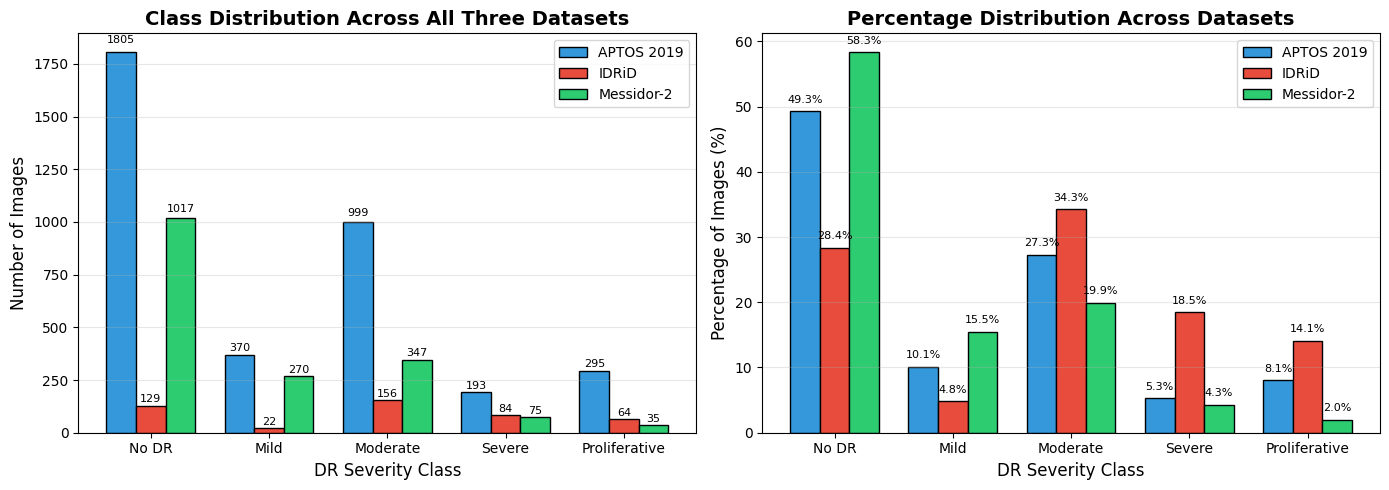


Comparison charts saved to: results/figures/dataset_comparison_charts.png

Chart Summary:
--------------------------------------------------
APTOS 2019: 3662 total images
IDRiD: 455 total images
Messidor-2: 1744 total images


In [9]:
# ============================================================================
# STEP 7: CREATE COMPARISON CHARTS
# ============================================================================

print("\n" + "=" * 80)
print("CREATING DATASET COMPARISON CHARTS")
print("=" * 80)

# Make sure all data is available
print("\nChecking data availability:")
print("-" * 50)

# Check APTOS data
if 'aptos_counts' in locals() and len(aptos_counts) > 0:
    print(f"APTOS data: {len(aptos_counts)} classes available")
    aptos_values = [aptos_counts.get(i, 0) for i in range(5)]
    print(f"  Counts: {aptos_values}")
else:
    print("APTOS data not available")
    aptos_values = [0, 0, 0, 0, 0]

# Check IDRiD data
if 'idrid_counts' in locals() and len(idrid_counts) > 0:
    print(f"IDRiD data: {len(idrid_counts)} classes available")
    idrid_values = [idrid_counts[i] if i < len(idrid_counts) else 0 for i in range(5)]
    print(f"  Counts: {idrid_values}")
else:
    print("IDRiD data not available")
    idrid_values = [0, 0, 0, 0, 0]

# Check Messidor data
if 'messidor_counts' in locals() and len(messidor_counts) > 0:
    print(f"Messidor data: {len(messidor_counts)} classes available")
    messidor_values = [messidor_counts[i] if i < len(messidor_counts) else 0 for i in range(5)]
    print(f"  Counts: {messidor_values}")
else:
    print("Messidor data not available")
    messidor_values = [0, 0, 0, 0, 0]

# Check if we have any data
if sum(aptos_values) == 0 and sum(idrid_values) == 0 and sum(messidor_values) == 0:
    print("\nWARNING: No data available for charts!")
    print("Please make sure you have loaded all datasets first.")
else:
    # Create a figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Define x positions for bars
    x = np.arange(len(class_names))
    width = 0.25
    
    # Plot 1: Class distribution comparison (Number of images)
    bars1 = ax1.bar(x - width, aptos_values, width, label='APTOS 2019', color='#3498db', edgecolor='black')
    bars2 = ax1.bar(x, idrid_values, width, label='IDRiD', color='#e74c3c', edgecolor='black')
    bars3 = ax1.bar(x + width, messidor_values, width, label='Messidor-2', color='#2ecc71', edgecolor='black')
    
    ax1.set_xlabel('DR Severity Class', fontsize=12)
    ax1.set_ylabel('Number of Images', fontsize=12)
    ax1.set_title('Class Distribution Across All Three Datasets', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(class_names)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Add numbers on bars for plot 1
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:  # Only add text if bar has height
                ax1.text(bar.get_x() + bar.get_width()/2., height + max(5, height * 0.02),
                        f'{int(height)}', ha='center', va='bottom', fontsize=8)
    
    # Plot 2: Percentage distribution comparison
    # Calculate percentages only if we have data
    aptos_total = sum(aptos_values)
    idrid_total = sum(idrid_values)
    messidor_total = sum(messidor_values)
    
    aptos_pct = [(c / aptos_total * 100) if aptos_total > 0 else 0 for c in aptos_values]
    idrid_pct = [(c / idrid_total * 100) if idrid_total > 0 else 0 for c in idrid_values]
    messidor_pct = [(c / messidor_total * 100) if messidor_total > 0 else 0 for c in messidor_values]
    
    bars1_pct = ax2.bar(x - width, aptos_pct, width, label='APTOS 2019', color='#3498db', edgecolor='black')
    bars2_pct = ax2.bar(x, idrid_pct, width, label='IDRiD', color='#e74c3c', edgecolor='black')
    bars3_pct = ax2.bar(x + width, messidor_pct, width, label='Messidor-2', color='#2ecc71', edgecolor='black')
    
    ax2.set_xlabel('DR Severity Class', fontsize=12)
    ax2.set_ylabel('Percentage of Images (%)', fontsize=12)
    ax2.set_title('Percentage Distribution Across Datasets', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(class_names)
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    # Add numbers on bars for plot 2
    for bars in [bars1_pct, bars2_pct, bars3_pct]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:  # Only add text if bar has height
                ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
                        f'{height:.1f}%', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    
    # Create results folder if it doesn't exist
    os.makedirs("../results/figures", exist_ok=True)
    
    # Save the figure
    plt.savefig("../results/figures/dataset_comparison_charts.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nComparison charts saved to: results/figures/dataset_comparison_charts.png")
    
    # Print summary of what was plotted
    print("\nChart Summary:")
    print("-" * 50)
    print(f"APTOS 2019: {aptos_total} total images")
    print(f"IDRiD: {idrid_total} total images")
    print(f"Messidor-2: {messidor_total} total images")

In [10]:
# ============================================================================
# STEP 8: FINAL SUMMARY AND STATISTICS
# ============================================================================

print("\n" + "=" * 80)
print("FINAL SUMMARY: ALL THREE DATASETS")
print("=" * 80)

# Create summary table
print("\nDATASET OVERVIEW:")
print("-" * 80)
print(f"{'Dataset':15} {'Total Images':>12} {'Classes':>10} {'Purpose':>30}")
print("-" * 80)
print(f"{'APTOS 2019':15} {len(aptos_dataset):>12} {'5':>10} {'Training (main dataset)':>30}")
print(f"{'IDRiD':15} {len(idrid_csv):>12} {'5':>10} {'Lesion validation':>30}")
print(f"{'Messidor-2':15} {len(messidor_clean):>12} {'5':>10} {'External testing':>30}")
print("-" * 80)

print("\nCLASS DISTRIBUTION SUMMARY:")
print("-" * 80)
print(f"{'Class':15} {'APTOS 2019':>12} {'IDRiD':>10} {'Messidor-2':>12}")
print("-" * 80)
for i, name in enumerate(class_names):
    aptos_count = aptos_counts.get(i, 0)
    idrid_count = idrid_counts[i] if i < len(idrid_counts) else 0
    messidor_count = messidor_counts[i] if i < len(messidor_counts) else 0
    print(f"{name:15} {aptos_count:>12} {idrid_count:>10} {messidor_count:>12}")
print("-" * 80)

# Calculate percentages
print("\nPERCENTAGE DISTRIBUTION:")
print("-" * 80)
print(f"{'Class':15} {'APTOS 2019':>12} {'IDRiD':>10} {'Messidor-2':>12}")
print("-" * 80)
for i, name in enumerate(class_names):
    aptos_pct = (aptos_counts.get(i, 0) / len(aptos_dataset)) * 100
    idrid_pct = (idrid_counts[i] / len(idrid_csv)) * 100 if i < len(idrid_counts) else 0
    messidor_pct = (messidor_counts[i] / len(messidor_clean)) * 100 if i < len(messidor_counts) else 0
    print(f"{name:15} {aptos_pct:>11.1f}% {idrid_pct:>9.1f}% {messidor_pct:>11.1f}%")
print("-" * 80)

# Save summary to JSON (with proper type conversion)
import json
import numpy as np

# Helper function to convert numpy types to Python native types
def convert_to_serializable(obj):
    """Convert numpy/pandas types to Python native types for JSON serialization"""
    if isinstance(obj, (np.int64, np.int32, np.int16, np.int8)):
        return int(obj)
    elif isinstance(obj, (np.float64, np.float32, np.float16)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {key: convert_to_serializable(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(item) for item in obj]
    else:
        return obj

# Build summary data
summary_data = {
    "datasets": {
        "aptos_2019": {
            "total_images": int(len(aptos_dataset)),
            "class_counts": {class_names[i]: int(aptos_counts.get(i, 0)) for i in range(5)},
            "class_percentages": {class_names[i]: float((aptos_counts.get(i, 0) / len(aptos_dataset)) * 100) for i in range(5)}
        },
        "idrid": {
            "total_images": int(len(idrid_csv)),
            "class_counts": {class_names[i]: int(idrid_counts[i]) for i in range(5)},
            "class_percentages": {class_names[i]: float((idrid_counts[i] / len(idrid_csv)) * 100) for i in range(5)}
        },
        "messidor_2": {
            "total_images": int(len(messidor_clean)),
            "gradable_images": int(len(messidor_clean)),
            "total_original": int(len(messidor_csv)),
            "excluded_poor_quality": int(len(messidor_csv) - len(messidor_clean)),
            "class_counts": {class_names[i]: int(messidor_counts[i]) for i in range(5)},
            "class_percentages": {class_names[i]: float((messidor_counts[i] / len(messidor_clean)) * 100) for i in range(5)}
        }
    }
}

# Add edema risk info if available
if 'Risk of macular edema' in idrid_csv.columns:
    edema_counts = idrid_csv['Risk of macular edema'].value_counts().sort_index()
    summary_data["datasets"]["idrid"]["edema_risk"] = {int(risk): int(count) for risk, count in edema_counts.items()}

# Add DME info if available
if 'adjudicated_dme' in messidor_clean.columns:
    dme_counts = messidor_clean['adjudicated_dme'].value_counts().sort_index()
    summary_data["datasets"]["messidor_2"]["dme"] = {int(dme): int(count) for dme, count in dme_counts.items()}

# Convert any remaining numpy types
summary_data = convert_to_serializable(summary_data)

# Create results folder if it doesn't exist
os.makedirs("../results", exist_ok=True)

# Save the file
with open("../results/dataset_summary.json", "w") as file:
    json.dump(summary_data, file, indent=2)

print("\nDataset summary saved to: results/dataset_summary.json")

# Also print a preview of what was saved
print("\nPreview of saved summary:")
print(json.dumps(summary_data, indent=2)[:500] + "...")


FINAL SUMMARY: ALL THREE DATASETS

DATASET OVERVIEW:
--------------------------------------------------------------------------------
Dataset         Total Images    Classes                        Purpose
--------------------------------------------------------------------------------
APTOS 2019              3662          5        Training (main dataset)
IDRiD                    455          5              Lesion validation
Messidor-2              1744          5               External testing
--------------------------------------------------------------------------------

CLASS DISTRIBUTION SUMMARY:
--------------------------------------------------------------------------------
Class             APTOS 2019      IDRiD   Messidor-2
--------------------------------------------------------------------------------
No DR                   1805        129         1017
Mild                     370         22          270
Moderate                 999        156          347
Severe          

In [12]:
# ============================================================================
# STEP 9: QUICK VERIFICATION - IS MY DATA READY?
# ============================================================================

print("\n" + "=" * 80)
print("STEP 9: QUICK VERIFICATION")
print("=" * 80)

print("\nLet me check if everything is ready for training...")

# ============================================================================
# CHECK 1: What will my model predict?
# ============================================================================

print("\n1. WHAT MY MODEL WILL PREDICT:")
print("-" * 50)
print("My model will look at an eye image and tell me which class it belongs to:")
print()

for i in range(5):
    print(f"   Class {i} = {class_names[i]}")
    print(f"      - {class_descriptions[i]}")
    print(f"      - Risk: {class_risk[i]['risk']}")
    print(f"      - Action: {class_risk[i]['action']}")
    print()

# ============================================================================
# CHECK 2: Do I have the right number of images?
# ============================================================================

print("\n2. HOW MANY IMAGES IN MY TRAINING DATA:")
print("-" * 50)
print(f"Total images for training: {len(aptos_dataset)}")
print()
print("Breakdown by severity:")
print()

for i in range(5):
    count = aptos_counts.get(i, 0)
    percentage = (count / len(aptos_dataset)) * 100
    print(f"   Class {i} ({class_names[i]}): {count:5} images ({percentage:5.1f}%)")

# ============================================================================
# CHECK 3: Is the class order correct?
# ============================================================================

print("\n3. CLASS ORDER CHECK:")
print("-" * 50)

# This is the most important check!
if aptos_counts.get(0, 0) == 1805:
    print("PASS: Class 0 = No DR (1,805 images) - CORRECT")
    print("      The healthy class is in the right position.")
else:
    print("WARNING: Class 0 =", aptos_counts.get(0, 0), "images (should be 1,805)")
    print("         Something is wrong with the class order!")

if aptos_counts.get(4, 0) == 193:
    print("PASS: Class 4 = Proliferative DR (193 images) - CORRECT")
    print("      The most severe class is in the right position.")
else:
    print("WARNING: Class 4 =", aptos_counts.get(4, 0), "images (should be 193)")
    print("         Something is wrong with the class order!")

# ============================================================================
# CHECK 4: Do I have all three datasets ready?
# ============================================================================

print("\n4. ALL THREE DATASETS:")
print("-" * 50)

print(f"PASS: APTOS 2019: {len(aptos_dataset):5} images (main training data)")
print(f"PASS: IDRiD:      {len(idrid_csv):5} images (lesion validation)")
print(f"PASS: Messidor-2: {len(messidor_clean):5} images (external testing)")

# ============================================================================
# CHECK 5: Any issues I should know about?
# ============================================================================

print("\n5. IMPORTANT NOTES:")
print("-" * 50)

# Check imbalance
healthy = aptos_counts.get(0, 0)
severe = aptos_counts.get(3, 0) + aptos_counts.get(4, 0)

print(f"NOTE: The dataset is imbalanced:")
print(f"      - Healthy eyes: {healthy} images ({healthy/len(aptos_dataset)*100:.1f}%)")
print(f"      - Severe cases: {severe} images ({severe/len(aptos_dataset)*100:.1f}%)")
print(f"      - I will handle this in Notebook 02 using class weights.")

# Check Messidor quality
if len(messidor_csv) > 0:
    excluded = len(messidor_csv) - len(messidor_clean)
    if excluded > 0:
        print(f"\nNOTE: Messidor-2 quality check:")
        print(f"      - Good quality images: {len(messidor_clean)}")
        print(f"      - Poor quality excluded: {excluded}")
        print(f"      - Using only good quality images for fair testing.")

# ============================================================================
# FINAL VERDICT
# ============================================================================

print("\n" + "=" * 80)
print("FINAL VERDICT")
print("=" * 80)

all_good = True

if aptos_counts.get(0, 0) != 1805:
    all_good = False
    print("FAIL: Class order is WRONG. Please check STEP 3 mapping.")
elif len(aptos_dataset) == 0:
    all_good = False
    print("FAIL: No APTOS data loaded. Please check STEP 3.")
elif len(idrid_csv) == 0:
    all_good = False
    print("FAIL: No IDRiD data loaded. Please check STEP 4.")
elif len(messidor_clean) == 0:
    all_good = False
    print("FAIL: No Messidor-2 data loaded. Please check STEP 5.")
else:
    print("\nPASS: ALL CHECKS PASSED!")
    print()
    print("My data is ready:")
    print(f"   - {len(aptos_dataset)} training images with correct ICDRSS labels")
    print(f"   - {len(idrid_csv)} images for lesion validation")
    print(f"   - {len(messidor_clean)} images for external testing")
    print()
    print("Class order is correct:")
    print(f"   - Class 0: No DR ({aptos_counts.get(0, 0)} images)")
    print(f"   - Class 1: Mild ({aptos_counts.get(1, 0)} images)")
    print(f"   - Class 2: Moderate ({aptos_counts.get(2, 0)} images)")
    print(f"   - Class 3: Severe ({aptos_counts.get(3, 0)} images)")
    print(f"   - Class 4: Proliferative ({aptos_counts.get(4, 0)} images)")

print("\n" + "=" * 80)
print("NOTEBOOK 01 COMPLETE")
print("=" * 80)
print("\nNEXT: Open Notebook 02 - Data Preprocessing")
print("")
print("In Notebook 02, I will:")
print("   - Add data augmentation (flips, rotations, color changes)")
print("   - Split data into train and validation sets")
print("   - Calculate class weights to handle imbalance")
print("   - Create data loaders for training")
print("=" * 80)


STEP 9: QUICK VERIFICATION

Let me check if everything is ready for training...

1. WHAT MY MODEL WILL PREDICT:
--------------------------------------------------
My model will look at an eye image and tell me which class it belongs to:

   Class 0 = No DR
      - No Diabetic Retinopathy - Healthy retina, no visible lesions
      - Risk: Low
      - Action: Regular annual eye checkups

   Class 1 = Mild
      - Mild DR - Microaneurysms only (tiny red dots)
      - Risk: Low to Moderate
      - Action: Monitor every 6-12 months

   Class 2 = Moderate
      - Moderate DR - Hemorrhages, exudates, more microaneurysms
      - Risk: Moderate to High
      - Action: Specialist review within 1-3 months

   Class 3 = Severe
      - Severe DR - Extensive hemorrhages in all four quadrants
      - Risk: High
      - Action: Immediate specialist referral

   Class 4 = Proliferative
      - Proliferative DR - Neovascularization (abnormal new blood vessels)
      - Risk: Critical
      - Action: Urg